# 36118 AT1: How Skilled Migration Is Framed in Public Submissions

**Research question:** Which expected-benefit, risk, and policy-condition themes recur across the supplied submissions, and how consistently do those themes co-occur?

This notebook develops a reproducible, corpus-wide baseline for the 2026 AT1. It audits PDF extraction, applies an explicit theme dictionary, compares document prevalence with length-normalised mention rates, and checks theme co-occurrence. Dictionary matches indicate that a topic is discussed; they do **not** reveal whether the submitter supports or opposes a policy.

## 1. Corpus and analytical design

The supplied corpus contains public submissions to the Australian parliamentary inquiry into the value of skilled migration. PDF extraction quality varies, so the first analytical decision is to account for every file and flag documents that may require OCR. The main analysis uses transparent phrase patterns rather than an opaque topic model. This makes each measurement traceable and leaves room for manual validation in the final report.

In [1]:
import logging
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pypdf import PdfReader

RANDOM_SEED = 42
EXPECTED_PDF_COUNT = 143
MIN_EXTRACTED_CHARACTERS = 500
FIGURE_SIZE = (9, 5)
DATA_RELATIVE_PATH = Path(
    "data/submissions-skilled-migration/submissions_Skilledmigration"
)
OCR_RELATIVE_PATH = Path("data/ocr_text")
VALIDATION_RELATIVE_PATH = Path("validation")

THEME_PATTERNS = {
    "Economic contribution": [
        r"\bproductivit",
        r"\beconomic (?:growth|contribution|benefit|value|impact)",
        r"\binnovation", r"\bfiscal (?:benefit|contribution|impact)",
        r"\btax revenue", r"\b(?:public|private|business) investment",
    ],
    "Skills and essential services": [
        r"\bskills? (?:gaps?|shortages?)",
        r"\b(?:labou?r|workforce|staff) shortages?",
        r"\bcritical (?:skills?|sectors?)",
        r"\b(?:health(?:care)?|aged care|education|teaching|construction) "
        r"(?:workforce|sectors?|services?)",
        r"\bessential services?",
    ],
    "Regional development": [
        r"\bregional australia", r"\bregional communit",
        r"\bregional development", r"\brural\b", r"\bremote areas?",
    ],
    "Worker protection and fairness": [
        r"\bexploit", r"\bunderpay", r"\bwage theft",
        r"\bwork(?:er|place) rights?", r"\blabou?r standards?",
        r"\bfair work", r"\bworker protections?", r"\bunsafe work",
    ],
    "Permanent pathways and retention": [
        r"\bpermanent residen", r"\bpathways? (?:to|towards?) permanen",
        r"\bretention\b", r"\bcitizenship\b", r"\bpermanency\b",
        r"\blong-term settlement",
    ],
    "Recognition and visa processing": [
        r"\bskills? recognition", r"\bqualification recognition",
        r"\bcredential recognition", r"\boverseas qualifications?",
        r"\bprocessing times?", r"\bvisa processing", r"\bpoints test",
        r"\boccupational licensing", r"\bprofessional registration",
    ],
    "Housing and infrastructure pressure": [
        r"\bhousing\b",
        r"\binfrastructure (?:capacity|constraints?|planning|investment|"
        r"shortages?|pressures?|needs?|supply|development)",
        r"\bcost of living", r"\bpopulation pressure",
    ],
}

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="viridis")
logging.getLogger("pypdf").setLevel(logging.ERROR)

### 1.1 Reproducible path discovery and extraction

In [2]:
def find_project_root(start: Path, data_path: Path) -> Path:
    """Find the AT1 directory without relying on a personal absolute path.

    Args:
        start: Directory from which to begin searching.
        data_path: Expected data location relative to the AT1 directory.

    Returns:
        The first parent directory containing the expected dataset.

    Raises:
        FileNotFoundError: If the dataset cannot be located.
    """
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / data_path).is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not find {data_path}. Run the notebook inside the AT1 folder."
    )


def submission_sort_key(path: Path) -> tuple[int, str]:
    """Create a stable numeric key while preserving source filenames."""
    match = re.search(r"sub(\d+)", path.stem, flags=re.IGNORECASE)
    number = int(match.group(1)) if match else 10**9
    return number, path.stem.lower()


def extract_pdf(path: Path) -> dict[str, object]:
    """Extract one PDF and retain quality information.

    Args:
        path: PDF to process.

    Returns:
        A record containing identifiers, text, counts, and any error.
    """
    try:
        reader = PdfReader(path)
        page_text = [page.extract_text() or "" for page in reader.pages]
        native_text = "\n".join(page_text)
        ocr_path = OCR_DIR / f"{path.stem}.txt"
        use_ocr = (
            len(native_text) < MIN_EXTRACTED_CHARACTERS and ocr_path.is_file()
        )
        text = ocr_path.read_text(encoding="utf-8") if use_ocr else native_text
        return {
            "submission_id": path.stem,
            "filename": path.name,
            "page_count": len(reader.pages),
            "text": text,
            "native_character_count": len(native_text),
            "extraction_method": "OCR sidecar" if use_ocr else "native PDF",
            "extraction_error": None,
        }
    except Exception as exc:  # Continue the audit if one source is malformed.
        return {
            "submission_id": path.stem,
            "filename": path.name,
            "page_count": 0,
            "text": "",
            "native_character_count": 0,
            "extraction_method": "failed",
            "extraction_error": f"{type(exc).__name__}: {exc}",
        }


PROJECT_ROOT = find_project_root(Path.cwd(), DATA_RELATIVE_PATH)
DATA_DIR = PROJECT_ROOT / DATA_RELATIVE_PATH
OCR_DIR = PROJECT_ROOT / OCR_RELATIVE_PATH
VALIDATION_DIR = PROJECT_ROOT / VALIDATION_RELATIVE_PATH
pdf_paths = sorted(DATA_DIR.glob("*.pdf"), key=submission_sort_key)

assert len(pdf_paths) == EXPECTED_PDF_COUNT, (
    f"Expected {EXPECTED_PDF_COUNT} PDFs, found {len(pdf_paths)} in {DATA_DIR}"
)

documents = pd.DataFrame(extract_pdf(path) for path in pdf_paths)
documents["character_count"] = documents["text"].str.len()
documents["word_count"] = documents["text"].str.findall(
    r"[A-Za-z]+(?:'[A-Za-z]+)?"
).str.len()
documents["needs_manual_review"] = (
    (documents["native_character_count"] < MIN_EXTRACTED_CHARACTERS)
    | documents["extraction_error"].notna()
)

print(f"AT1 project located: {PROJECT_ROOT.name}")
print(f"PDFs accounted for: {len(documents)}")
print(f"Pages extracted: {documents['page_count'].sum():,}")
print(f"Extraction errors: {documents['extraction_error'].notna().sum()}")
print(f"OCR sidecars loaded: {(documents['extraction_method'] == 'OCR sidecar').sum()}")

AT1 project located: at1
PDFs accounted for: 143
Pages extracted: 1,670
Extraction errors: 0
OCR sidecars loaded: 4


## 2. Extraction-quality audit

,page_count,character_count,word_count
count,143.0,143.0,143.0
mean,11.7,27436.3,3736.0
std,15.0,39582.0,5555.7
min,1.0,567.0,80.0
25%,4.0,9338.5,1231.0
50%,7.0,16340.0,2165.0
75%,12.0,28973.5,4014.0
max,121.0,295143.0,41656.0


,submission_id,filename,page_count,native_character_count,character_count,word_count,extraction_method,extraction_error
139,Sub141,Sub141.pdf,1,73,2510,84,OCR sidecar,None
132,Sub134,Sub134.pdf,3,215,4955,502,OCR sidecar,None
111,Sub110,Sub110.pdf,4,287,9379,1156,OCR sidecar,None
99,Sub098,Sub098.pdf,6,425,14171,1705,OCR sidecar,None


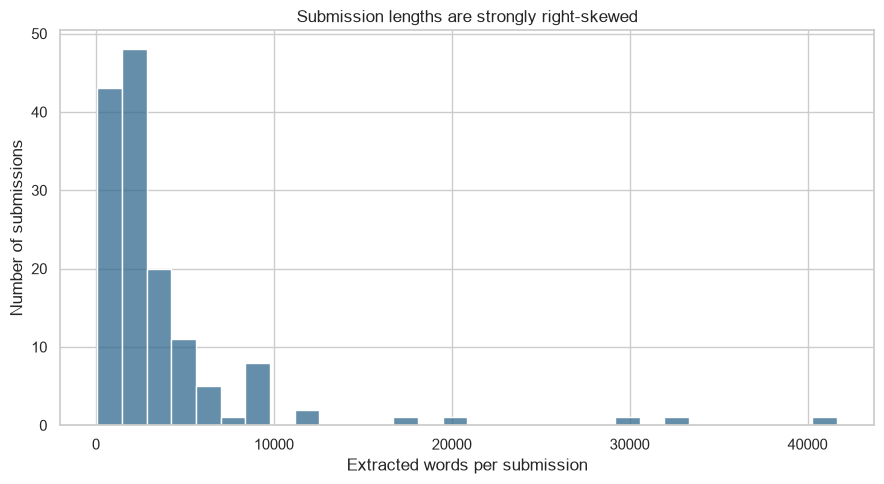

In [3]:
quality_summary = documents[[
    "page_count", "character_count", "word_count"
]].describe().round(1)
display(quality_summary)

review_columns = [
    "submission_id", "filename", "page_count", "native_character_count",
    "character_count", "word_count", "extraction_method", "extraction_error",
]
manual_review = documents.loc[
    documents["needs_manual_review"], review_columns
].sort_values("character_count")
display(manual_review)

fig, ax = plt.subplots(figsize=FIGURE_SIZE)
sns.histplot(documents["word_count"], bins=30, ax=ax, color="#31688e")
ax.set(
    title="Submission lengths are strongly right-skewed",
    xlabel="Extracted words per submission",
    ylabel="Number of submissions",
)
plt.tight_layout()
plt.show()

**Interpretation.** All 143 supplied files can be opened. Four are image-based rather than genuinely short: `Sub098`, `Sub110`, `Sub134`, and `Sub141`. Local OCR sidecars recover substantial content for inspection, but spacing quality—especially in `Sub141`—makes their token counts non-comparable with native extraction. The quantitative denominator therefore remains the 139 native-text submissions. Document lengths vary substantially, so the main analysis reports both document prevalence and mentions per 10,000 words.

### 2.1 OCR recovery and human validation evidence

OCR is an optional preprocessing step run by `scripts/ocr_low_text_pdfs.py`; it is not hidden inside the main analysis. The generated sidecars remain beside the ignored raw data. Human judgments from the seeded 18-submission audit are stored in a small tracked CSV so the notebook can report exactly what was checked.

In [4]:
ocr_evidence = documents.loc[
    documents["extraction_method"] == "OCR sidecar",
    [
        "submission_id", "page_count", "native_character_count",
        "character_count", "extraction_method",
    ],
].rename(columns={"character_count": "ocr_character_count"})
display(ocr_evidence)

validation_audit = pd.read_csv(
    VALIDATION_DIR / "theme_validation_audit.csv"
)
validation_summary = (
    validation_audit.groupby(["audit_type", "judgment"])
    .size()
    .rename("submissions")
    .reset_index()
)
display(validation_summary)
assert validation_audit["submission_id"].nunique() == 18

,submission_id,page_count,native_character_count,ocr_character_count,extraction_method
99,Sub098,6,425,14171,OCR sidecar
111,Sub110,4,287,9379,OCR sidecar
132,Sub134,3,215,4955,OCR sidecar
139,Sub141,1,73,2510,OCR sidecar


,audit_type,judgment,submissions
0,positive match,true match,14
1,recall probe,ambiguous boundary,1
2,recall probe,correct non-match,2
3,recall probe,false negative,1


## 3. Transparent thematic measurement

The theme dictionary operationalises concepts suggested by the inquiry context: economic contribution, skills and services, regional development, worker protection, permanence, recognition and processing, and infrastructure pressure. Patterns deliberately use stems and small phrase families. They are inspectable but not exhaustive; polysemy and negation remain important limitations.

In [5]:
def normalise_text(text: str) -> str:
    """Lowercase text and collapse whitespace without removing negation."""
    return re.sub(r"\s+", " ", text.lower()).strip()


def count_theme_mentions(
    text: str,
    theme_patterns: dict[str, list[str]],
) -> dict[str, int]:
    """Count all configured pattern matches in one document.

    Args:
        text: Normalised document text.
        theme_patterns: Mapping from theme names to regex patterns.

    Returns:
        Match count for every theme.
    """
    return {
        theme: sum(len(re.findall(pattern, text)) for pattern in patterns)
        for theme, patterns in theme_patterns.items()
    }


usable = documents.loc[
    (documents["extraction_method"] == "native PDF")
    & documents["extraction_error"].isna()
    & (documents["native_character_count"] >= MIN_EXTRACTED_CHARACTERS)
].copy()
usable["normalised_text"] = usable["text"].map(normalise_text)
theme_counts = pd.DataFrame(
    usable["normalised_text"].map(
        lambda text: count_theme_mentions(text, THEME_PATTERNS)
    ).tolist(),
    index=usable.index,
)

total_words = usable["word_count"].sum()
theme_summary = pd.DataFrame({
    "documents_mentioning": (theme_counts > 0).sum(),
    "document_prevalence_pct": (theme_counts > 0).mean() * 100,
    "total_mentions": theme_counts.sum(),
    "mentions_per_10k_words": theme_counts.sum() / total_words * 10_000,
}).sort_values("document_prevalence_pct", ascending=False)

display(theme_summary.round(2))

,documents_mentioning,document_prevalence_pct,total_mentions,mentions_per_10k_words
Skills and essential services,129,92.81,1542,29.05
Economic contribution,119,85.61,1653,31.14
Permanent pathways and retention,97,69.78,891,16.79
Housing and infrastructure pressure,96,69.06,856,16.13
Recognition and visa processing,85,61.15,659,12.42
Regional development,80,57.55,669,12.60
Worker protection and fairness,44,31.65,478,9.01


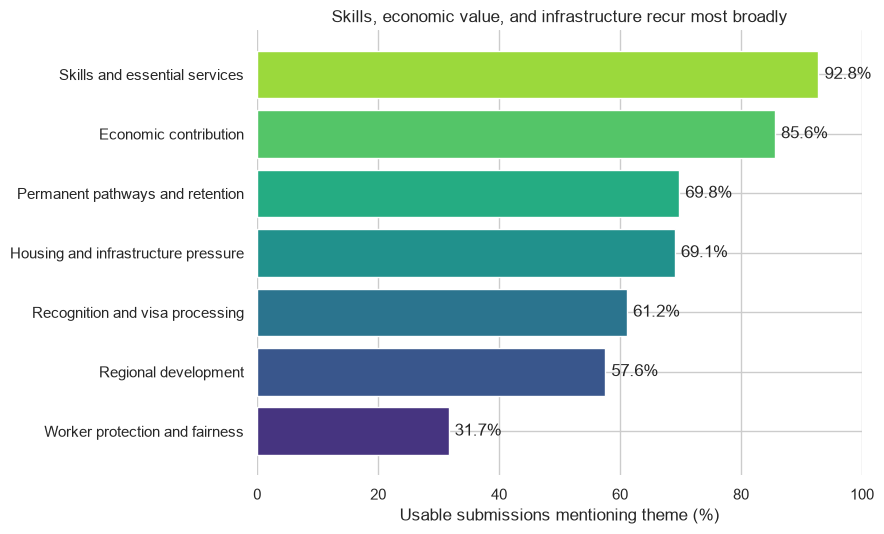

In [6]:
plot_data = theme_summary.sort_values("document_prevalence_pct")
fig, ax = plt.subplots(figsize=(9, 5.5))
colours = plt.colormaps["viridis"](
    np.linspace(0.15, 0.85, len(plot_data))
)
ax.barh(
    plot_data.index,
    plot_data["document_prevalence_pct"],
    color=colours,
)
ax.set(
    title="Skills, economic value, and infrastructure recur most broadly",
    xlabel="Usable submissions mentioning theme (%)",
    ylabel="",
    xlim=(0, 100),
)
for index, value in enumerate(plot_data["document_prevalence_pct"]):
    ax.text(value + 1, index, f"{value:.1f}%", va="center")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

**Interpretation.** After validation-driven refinement, skills and essential services appear in about 92.8% of usable submissions, followed by economic contribution (85.6%). Housing and infrastructure pressure and permanent pathways each occur in about 69%, while explicit worker-protection language appears in about 31.7%. Narrowing bare words such as “education” and “infrastructure” reduced false matches from affiliations and the inquiry terms of reference. These are measures of topical presence, not endorsement.

### 3.1 Theme co-occurrence

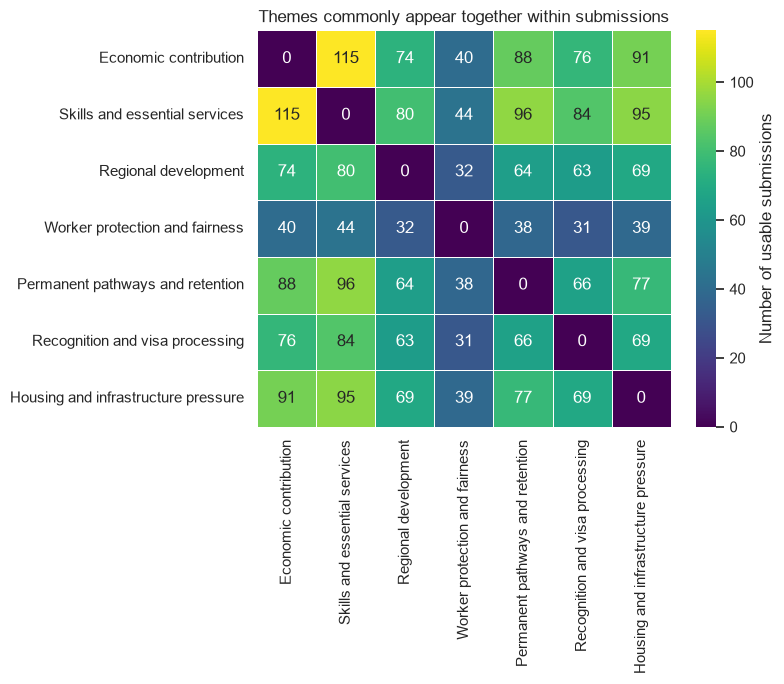

In [7]:
theme_presence = (theme_counts > 0).astype(int)
co_occurrence = theme_presence.T.dot(theme_presence)
np.fill_diagonal(co_occurrence.values, 0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    co_occurrence,
    cmap="viridis",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Number of usable submissions"},
    ax=ax,
)
ax.set_title("Themes commonly appear together within submissions")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretation.** Co-occurrence prevents the analysis from forcing submissions into one-topic categories. The strongest intersections should be read as linked policy frames—for example, discussion of skills can coexist with economic value, service delivery, infrastructure capacity, or migration pathways. In the final report, the highest-frequency pairs should be checked against representative source passages to determine how the connection is argued.

### 3.2 Source-verified representative excerpts

Co-occurrence counts show that topics appear in the same document, but they do not explain the relationship between those topics. The following short excerpts were manually checked against the named source PDF and page. They illustrate the three most common relationships without treating one quotation as representative of every submitter.

In [8]:
representative_excerpts = pd.read_csv(
    VALIDATION_DIR / "representative_excerpts.csv"
)
display(
    representative_excerpts[[
        "relationship", "submission_id", "pdf_page",
        "verified_excerpt", "analytical_use",
    ]]
)

,relationship,submission_id,pdf_page,verified_excerpt,analytical_use
0,Economic contribution + Skills and essential s...,Sub057,7,"Skills shortages constrain business growth, pr...",Links an identified labour constraint directly...
1,Skills and essential services + Permanent path...,Sub019,5,Fast-tracking permanent residency for critical...,Frames permanence as a mechanism for retaining...
2,Skills and essential services + Housing and in...,Sub094,5,Migrants can only remain in regional communiti...,"Connects workforce retention to housing, servi..."


**Interpretation.** The excerpts make the recurring policy logic concrete. `Sub057` treats skills shortages as constraints on productivity and innovation. `Sub019` presents permanent residency as a way to secure critical talent, while `Sub094` argues that regional retention depends on housing, services, and stable community life. Together they support a conditional framing: skilled migration creates value when migration pathways and settlement capacity allow skills to be used and retained.

## 4. Findings, limitations, and next steps

The baseline indicates that the value of skilled migration is framed most consistently through **skills and essential services** and **economic contribution**, but a large majority of documents also discuss **housing or infrastructure** and **permanent pathways**. This supports a multi-dimensional account: submissions connect workforce value to the conditions under which migrants and communities can sustain that value.

Important limitations remain. Four image-based PDFs are available through OCR sidecars for inspection but excluded from quantitative rates because their tokenisation quality differs from native text. A reproducible 18-submission validation audit narrowed noisy patterns, bounded the permanent-pathway regex, and added “long-term settlement” after identifying a false negative. Three source-verified excerpts explain the strongest co-occurrence relationships, but they do not represent every submitter. Regex patterns can still miss synonyms or match a concept used negatively. The analysis does not yet distinguish submitter type, stance, or recommendation strength. A useful extension is submitter metadata, but only if identities can be mapped reliably.